In [18]:
import matplotlib.pyplot as plt
import pandas as pd

In [19]:
import os

directory = "/workspaces/CUBES/results"
file_name = "all_months_air_ooh_all_months.csv"

for root, dirs, files in os.walk(directory):
    if file_name in files:
        file_path = os.path.join(root, file_name)
        file_size = os.path.getsize(file_path) / (1024 * 1024)  # File size in MB
        print(f"{file_path}: {file_size:.2f} MB")


/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_0_inactive_threshold_30_pattern_once_t_comfort_18.0_t_setback_16.0_tags_thermostat_final_v4/all_months_air_ooh_all_months.csv: 0.00 MB
/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_0_inactive_threshold_30_pattern_once_t_comfort_19.0_t_setback_16.0_tags_thermostat_final_v4/all_months_air_ooh_all_months.csv: 0.00 MB
/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_0_inactive_threshold_30_pattern_once_t_comfort_20.0_t_setback_16.0_tags_thermostat_final_v4/all_months_air_ooh_all_months.csv: 0.00 MB
/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_0_inactive_threshold_30_pattern_once_t_comfort_21.0_t_setback_16.0_tags_thermostat_final_v4/all_months_air_ooh_all_months.csv: 0.00 MB
/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_0_inactive_threshold_30_pattern_once_t_comfort_22.0_t_setback_16.0_tags_thermostat_final_v4/all_months_air_ooh_all_months.csv: 0.00 MB
/workspaces/CUBES/results/case_0_year_2023_re

In [10]:
results_dir = "/workspaces/CUBES/results/case_0_year_2023_rep_H28_zone_0_inactive_threshold_30_pattern_once_t_comfort_20.0_t_setback_16.0_tags_thermostat_final_v4"

file = "all_months_air_all_months.csv"

df = pd.read_csv(f"{results_dir}/{file}")

In [14]:



kitchen = df[(df["Zone"] == "kitchen") & ((df["Month"] < 4) | (df["Month"] >= 10))]
kitchen = kitchen.T

kitchen.columns = kitchen.iloc[0]
kitchen = kitchen.iloc[2:, :]

# Convert index to float, round it to 1 decimal place, and set it back
kitchen.index = pd.Series(kitchen.index).astype(float).round(1)

In [15]:
kitchen

Month,1,2,3,10,11,12
14.0,0,0,0,0,0,0
14.1,0,0,0,0,0,0
14.2,0,0,0,0,0,0
14.3,0,0,0,0,0,0
14.4,0,0,0,0,0,0
...,...,...,...,...,...,...
39.5,0,0,0,0,0,0
39.6,0,0,0,0,0,0
39.7,0,0,0,0,0,0
39.8,0,0,0,0,0,0


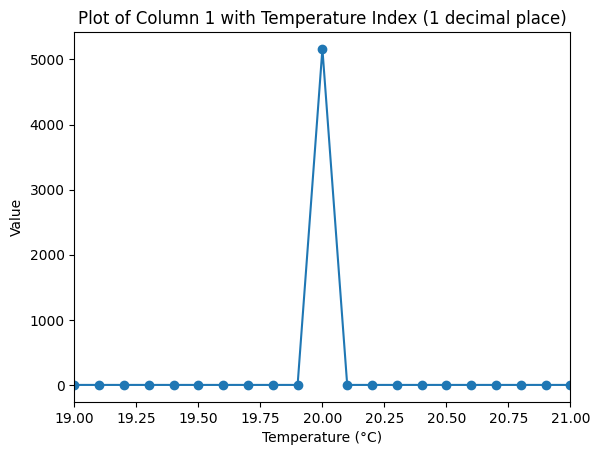

In [17]:


# Plot column '1' against the rounded index
kitchen[1].plot(marker='o')
plt.xlabel("Temperature (°C)")
plt.xlim(19,21)
plt.ylabel("Value")
plt.title("Plot of Column 1 with Temperature Index (1 decimal place)")
plt.show()


In [71]:
kitchen

Month,1,2,3,4,10,11,12
14.0,0,0,0,0,0,0,0
14.1,0,0,0,0,0,0,0
14.2,0,0,0,0,0,0,0
14.299999999999999,0,0,0,0,0,0,0
14.399999999999999,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...
39.49999999999991,0,0,0,0,0,0,0
39.59999999999991,0,0,0,0,0,0,0
39.69999999999991,0,0,0,0,0,0,0
39.79999999999991,0,0,0,0,0,0,0


AttributeError: 'Float64Index' object has no attribute 'round'

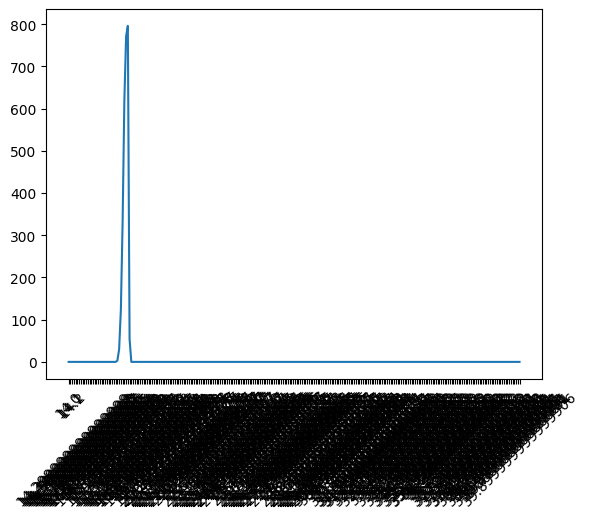

In [70]:
import matplotlib.pyplot as plt


# Plot the data
ax = kitchen[2].plot()

# Set x-axis ticks to increments of 1
ax.set_xticks(range(len(kitchen[2].index)))  # Set ticks at every index position
ax.set_xticklabels(kitchen[2].index, rotation=45)  # Use index values as labels with rotation

plt.show()


In [39]:

# Assuming `df` is the DataFrame you provided
summed_df = df.drop(columns=['Month', 'Zone']).sum(axis=0).to_frame().T  # Sum all rows in each column and transpose
summed_df.columns = df.columns[2:]  # Keep original column names

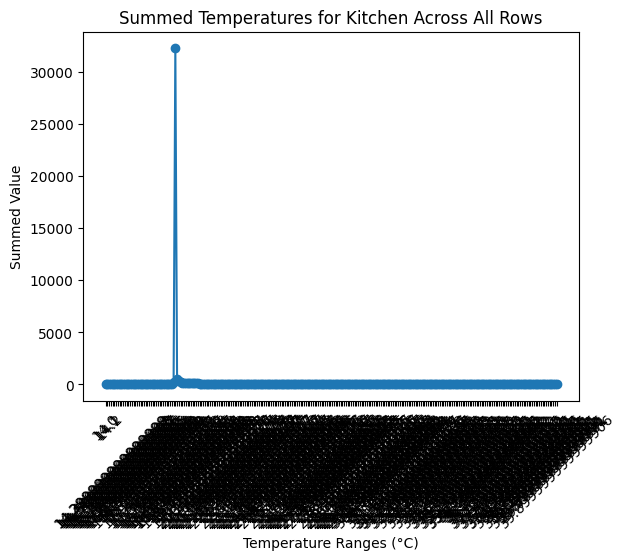

In [ ]:


# Plot the summed data
plt.plot(summed_df.columns, summed_df.iloc[0], marker='o')
plt.title("Summed Temperatures for Kitchen Across All Rows")
plt.xlabel("Temperature Ranges (°C)")
plt.ylabel("Summed Value")
plt.xticks(rotation=45)
plt.show()


In [27]:


# Assuming `df` is the DataFrame you provided
summed_df = df.drop(columns=['Month', 'Zone']).sum().to_frame().T  # Summing all numeric columns and transposing
# summed_df.insert(0, 'Month', 'Total')  # Optional label for month
# summed_df.insert(1, 'Zone', 'kitchen')  # Optional label for zone

summed_df


,14.0,14.1,14.2,14.299999999999999,14.399999999999999,14.499999999999998,14.599999999999998,14.699999999999998,14.799999999999997,14.899999999999997,...,38.999999999999915,39.09999999999991,39.19999999999991,39.29999999999991,39.399999999999906,39.49999999999991,39.59999999999991,39.69999999999991,39.79999999999991,39.899999999999906
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<Axes: >

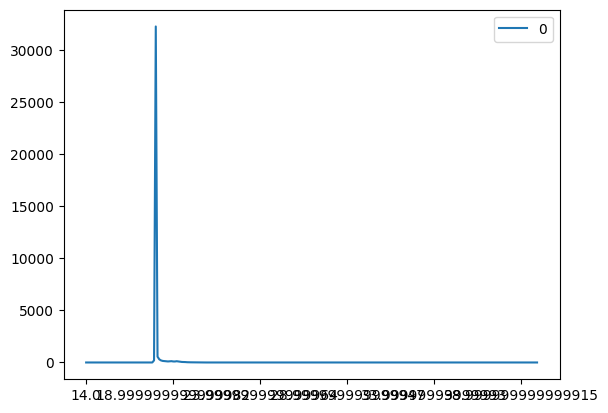

In [29]:
summed_df.T.plot()

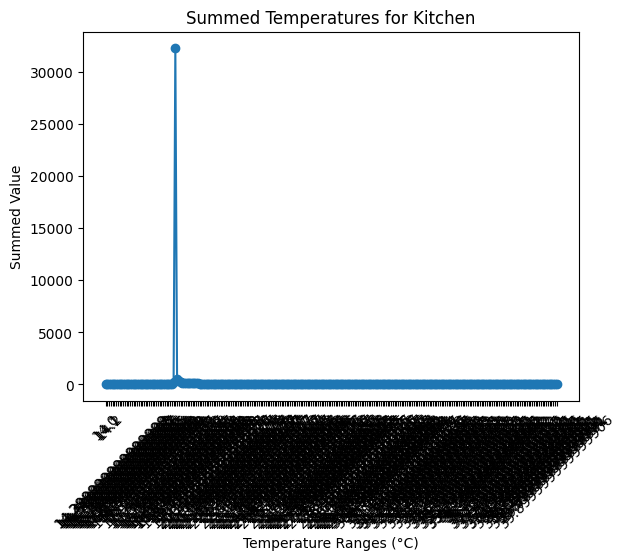

In [22]:
import matplotlib.pyplot as plt

# Plot the summed row data
plt.plot(summed_df.columns[2:], summed_df.iloc[0, 2:], marker='o')
plt.title("Summed Temperatures for Kitchen")
plt.xlabel("Temperature Ranges (°C)")
plt.ylabel("Summed Value")
plt.xticks(rotation=45)
plt.show()
